# Memoria inflamatoria en células madre humanas

Una infección aguda termina. Pero ¿deja huella en las células madre que fabrican toda tu sangre?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Human haematopoietic stem cells remember inflammatory stress*
**Journal:** Nature ([DOI: 10.1038/s41586-026-10522-7](https://doi.org/10.1038/s41586-026-10522-7))

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-29-celulas-madre-memoria-inflamatoria/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/vNq46Ohz2VE)


## El contexto

Las **células madre hematopoyéticas (HSCs)** son la fábrica que mantiene tu sangre toda la vida. Viven en la médula ósea, autorrenovándose por décadas.

Cuando llega una infección — bacteriana (modelada con **LPS**) o viral (modelada con **TNFα**, la citoquina maestra de la inflamación) — esas células reciben el aviso. La pregunta es qué pasa **después** de que la infección termina. ¿Las HSCs vuelven a su estado basal, o guardan memoria del estrés?

Para responder, sigamos el experimento: HSCs humanas (de sangre de cordón) trasplantadas a ratones inmunodeficientes, expuestas a inflamación, recuperadas, y luego secuenciadas — transcriptoma y cromatina. Después, a buscar la huella en humanos reales: cohortes post-COVID, anemia falciforme, envejecimiento, y hematopoyesis clonal (CH) — la condición donde un clon mutante crece silenciosamente con la edad.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_PBS = '#BBBBBB'         # Control sin tratamiento
COLOR_TNFA = '#2563EB'        # Estímulo viral (TNFα)
COLOR_LPS = '#DC2626'         # Estímulo bacteriano (LPS)
COLOR_HSC_I = '#7C3AED'       # HSC clásica (sin memoria)
COLOR_HSC_iM = '#059669'      # HSC con memoria inflamatoria
COLOR_CONTROL = '#BBBBBB'
COLOR_CH = '#DC2626'
FUENTE = 'Fuente: Schaerli et al., Nature 2026 · Datos: Supplementary Tables del paper'

# ───── Setup ─────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM: buscar local, fallback a /tmp, fallback a GitHub
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ───── Carga de datos ─────
ds1 = pd.read_csv('datos/hsc_frecuencia_inflamacion.csv')          # Fig 1g — xenograft
ds2 = pd.read_csv('datos/firma_lthsc_por_subset.csv')              # Fig 2c/2d — firma LT-HSC
ds3 = pd.read_csv('datos/clonal_haematopoiesis_hscim.csv')         # Fig 4h — CH humana
ds4 = pd.read_csv('datos/hscim_sangre_periferica_efectos.csv')     # Fig 5j — periferia

print(f'ds1 (xenograft): {len(ds1)} mediciones · {ds1.donante.nunique()} donantes · tratamientos: {sorted(ds1.tratamiento.unique())}')
print(f'ds2 (firma LT-HSC): {len(ds2)} filas · modalidades: {sorted(ds2.modalidad.unique())}')
print(f'ds3 (CH humana): {len(ds3)} sujetos · estados: {sorted(ds3.estado_ch.unique())}')
print(f'ds4 (periferia): {len(ds4)} contrastes · programas: {sorted(ds4.programa.unique())} · cohortes: {sorted(ds4.cohorte.unique())}')

ds1 (xenograft): 44 mediciones · 3 donantes · tratamientos: ['LPS', 'PBS', 'TNFα']
ds2 (firma LT-HSC): 12 filas · modalidades: ['Cromatina (ATAC LT-HSC)', 'RNA (LT-HSC vs MPP/LMPP)']
ds3 (CH humana): 13 sujetos · estados: ['Control', 'DNMT3A', 'DNMT3A_TET2', 'TET2']
ds4 (periferia): 24 contrastes · programas: ['HSC-I', 'HSC-iM'] · cohortes: ['Joven', 'Mayor']


## La marca queda

Veamos qué pasa con la frecuencia de HSCs después del estímulo inflamatorio.

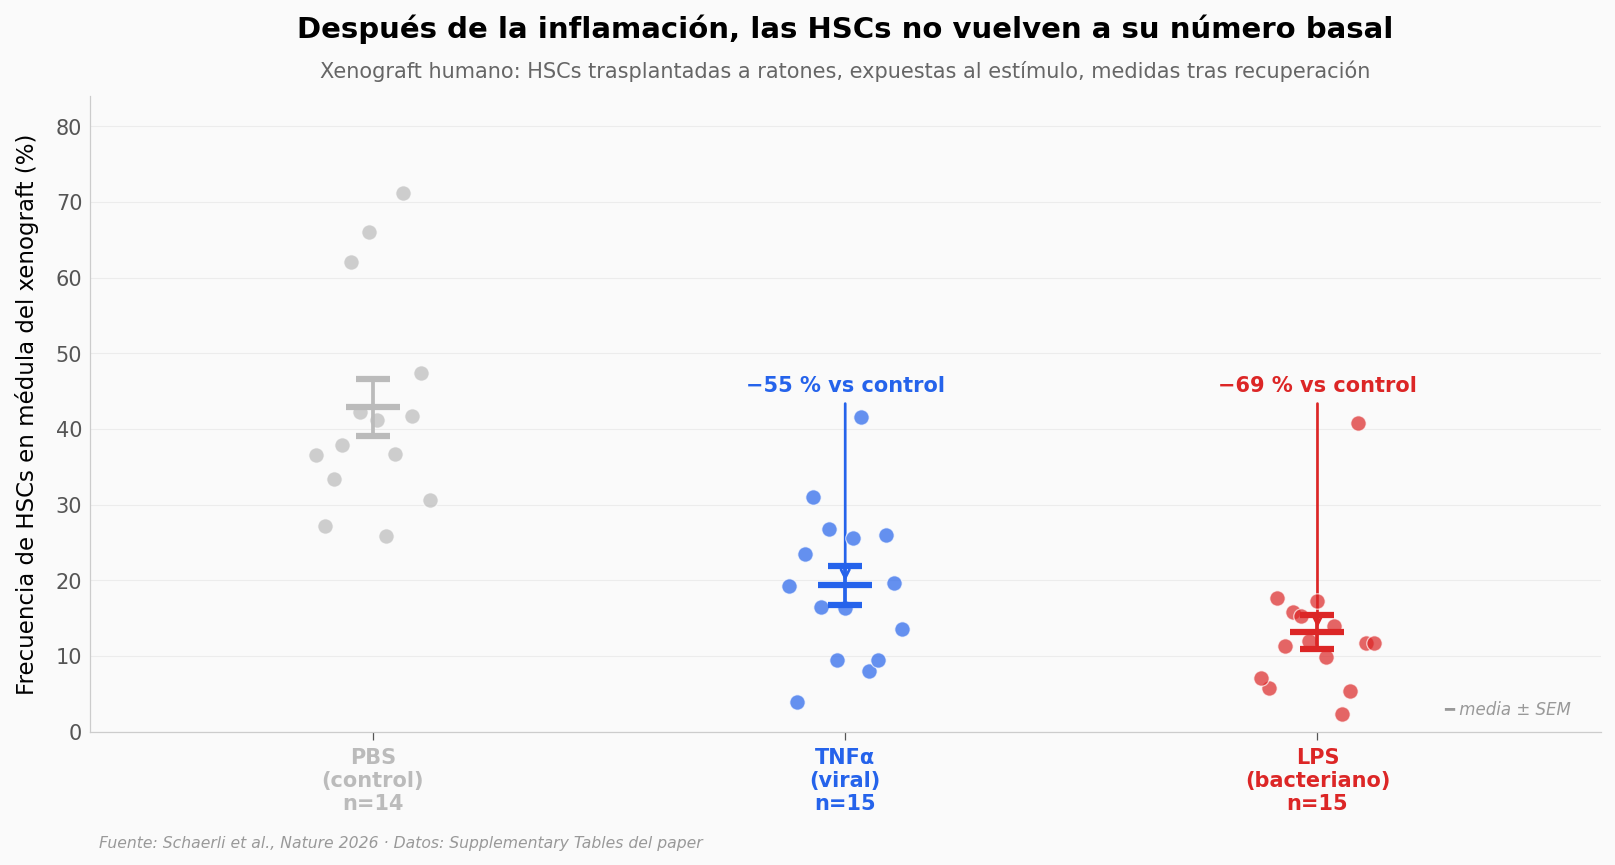

PBS vs TNFα: Mann-Whitney p=3.26e-05 · Cohen’s d=1.93 (grande)
PBS vs LPS:  Mann-Whitney p=1.04e-05 · Cohen’s d=2.53 (grande)


In [2]:
# ───── Gráfica hero: HSCs por tratamiento (Fig 1g) ─────
fig, ax = plt.subplots(figsize=(13, 5.5))

# Orden + paleta
orden = ['PBS', 'TNFα', 'LPS']
colores = {'PBS': COLOR_PBS, 'TNFα': COLOR_TNFA, 'LPS': COLOR_LPS}
positions = [0, 1, 2]

# Jitter reproducible
np.random.seed(42)
medias = []
sems = []
for i, trat in enumerate(orden):
    vals = ds1.loc[ds1.tratamiento == trat, 'pct_hsc'].values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.12, positions[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=colores[trat], s=55, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    medias.append(media); sems.append(sem)
    ax.errorbar(positions[i], media, yerr=sem, fmt='_', color=colores[trat],
                markersize=26, markeredgewidth=3, capsize=8, capthick=1.6, zorder=6)

# Ejes y etiquetas
ax.set_xticks(positions)
ax.set_xticklabels([f'PBS\n(control)\nn={(ds1.tratamiento=="PBS").sum()}',
                    f'TNFα\n(viral)\nn={(ds1.tratamiento=="TNFα").sum()}',
                    f'LPS\n(bacteriano)\nn={(ds1.tratamiento=="LPS").sum()}'],
                   fontsize=10, fontweight='bold')
for tick, trat in zip(ax.get_xticklabels(), orden):
    tick.set_color(colores[trat])
ax.set_ylabel('Frecuencia de HSCs en médula del xenograft (%)', fontsize=11)
ax.set_ylim(0, max(ds1.pct_hsc) * 1.18)
ax.set_xlim(-0.6, 2.6)

# Título + subtítulo
ax.set_title('Después de la inflamación, las HSCs no vuelven a su número basal',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Xenograft humano: HSCs trasplantadas a ratones, expuestas al estímulo, medidas tras recuperación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación de cambio porcentual
red_tnfa = (1 - medias[1] / medias[0]) * 100
red_lps = (1 - medias[2] / medias[0]) * 100
ax.annotate(f'−{red_tnfa:.0f} % vs control', xy=(1, medias[1]), xytext=(1.0, medias[0] * 1.05),
            ha='center', fontsize=10, fontweight='bold', color=COLOR_TNFA,
            arrowprops=dict(arrowstyle='->', color=COLOR_TNFA, lw=1.3))
ax.annotate(f'−{red_lps:.0f} % vs control', xy=(2, medias[2]), xytext=(2.0, medias[0] * 1.05),
            ha='center', fontsize=10, fontweight='bold', color=COLOR_LPS,
            arrowprops=dict(arrowstyle='->', color=COLOR_LPS, lw=1.3))

# Nota leyenda
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_frecuencia_hsc.png', dpi=200, bbox_inches='tight')
plt.show()

# Tests estadísticos (Mann-Whitney, no paramétrico)
vals_pbs = ds1.loc[ds1.tratamiento == 'PBS', 'pct_hsc'].values
vals_tnfa = ds1.loc[ds1.tratamiento == 'TNFα', 'pct_hsc'].values
vals_lps = ds1.loc[ds1.tratamiento == 'LPS', 'pct_hsc'].values

def cohens_d(a, b):
    pooled_sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_sd

_, p_tnfa = stats.mannwhitneyu(vals_pbs, vals_tnfa, alternative='greater')
_, p_lps = stats.mannwhitneyu(vals_pbs, vals_lps, alternative='greater')
print(f'PBS vs TNFα: Mann-Whitney p={p_tnfa:.2e} · Cohen\u2019s d={cohens_d(vals_pbs, vals_tnfa):.2f} (grande)')
print(f'PBS vs LPS:  Mann-Whitney p={p_lps:.2e} · Cohen\u2019s d={cohens_d(vals_pbs, vals_lps):.2f} (grande)')

La reducción no es sutil: tras TNFα baja a la mitad; tras LPS, a una tercera parte. Y la dispersión por donante es modesta — los 3 donantes responden en la misma dirección.

Pero aquí está la pieza interesante: al perfilar esas HSCs sobrevivientes con secuenciación de RNA y cromatina, no aparece una sola población — aparecen **dos**.

- **HSC-I**: la HSC clásica, similar al control.
- **HSC-II** (que el paper llama **HSC-iM**, *inflammatory memory*): comparte la identidad de "tronco" con HSC-I pero arrastra una huella inflamatoria persistente.

La pregunta crítica: ¿HSC-iM sigue siendo una HSC "de verdad" — capaz de autorrenovarse a largo plazo —, o es un progenitor desviado que ya perdió esa capacidad?

## ¿Sigue siendo HSC?

Veamos dos lecturas independientes: la **firma transcripcional** de las LT-HSC (long-term HSC, las verdaderamente troncales) en RNA-seq, y la **firma de cromatina** abierta (ATAC-seq) de las mismas regiones. Si HSC-iM es HSC bona fide, ambas firmas deberían parecerse a HSC-I.

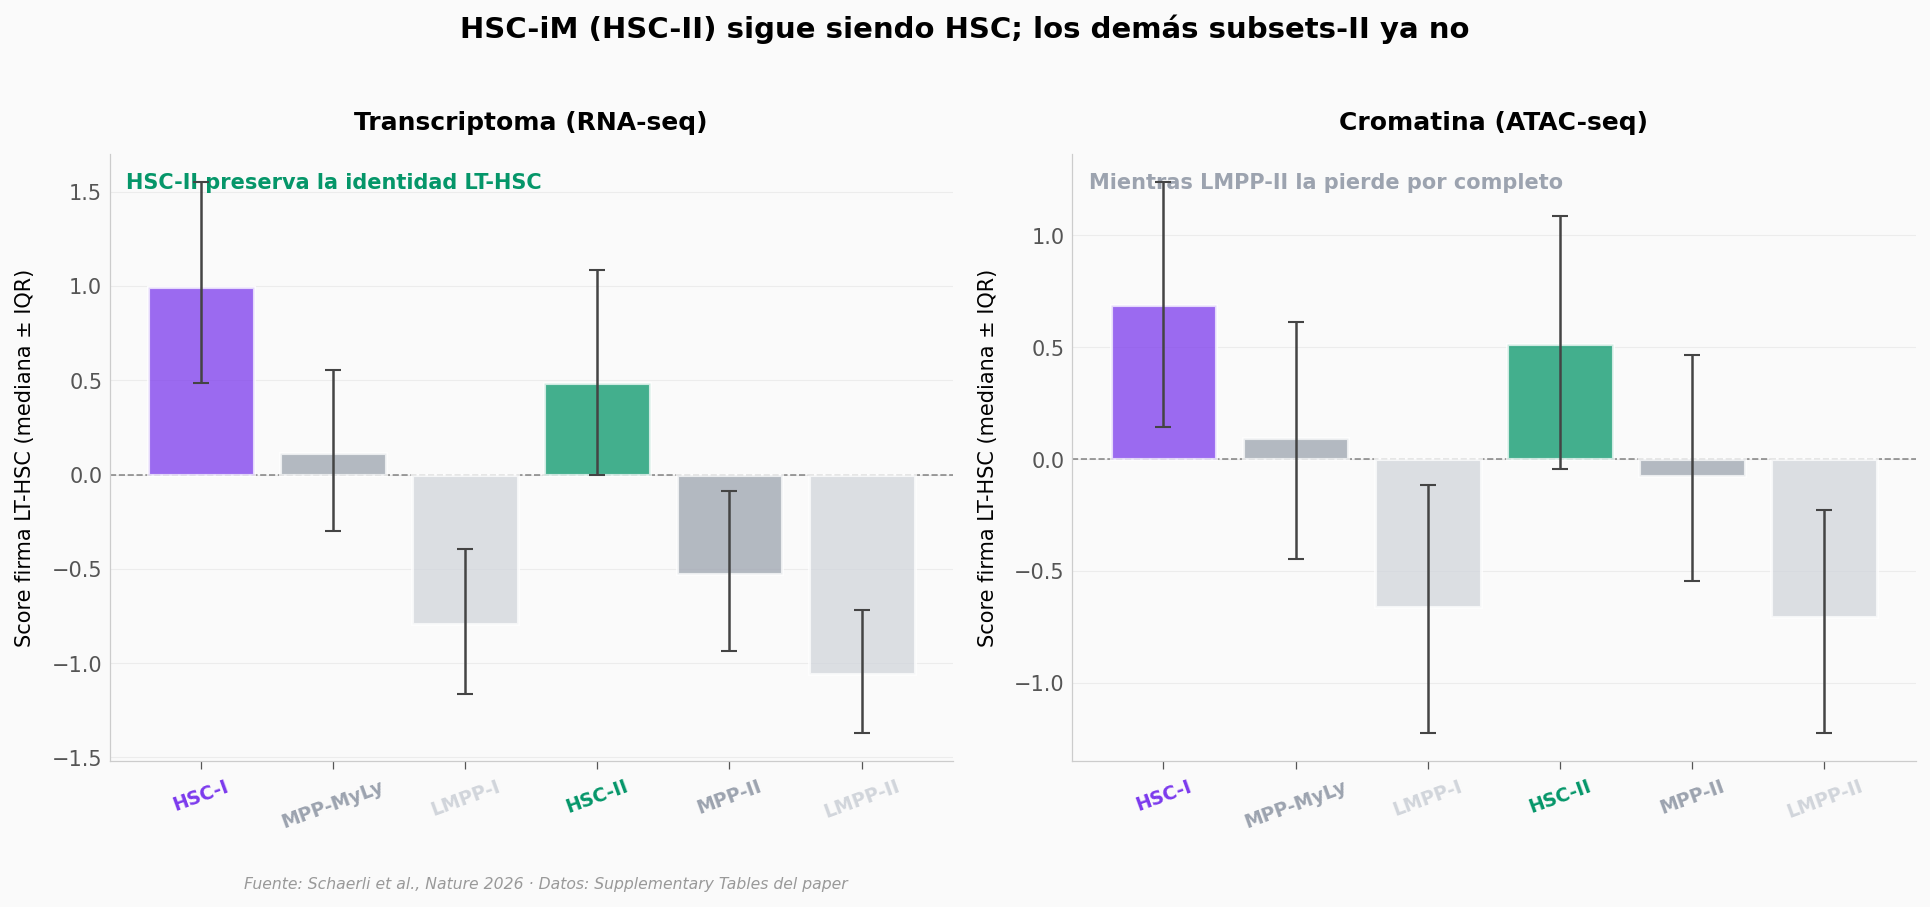

RNA (LT-HSC vs MPP/LMPP): HSC-I=1.00 · HSC-II=0.49 · LMPP-II=-1.06
Cromatina (ATAC LT-HSC): HSC-I=0.69 · HSC-II=0.51 · LMPP-II=-0.71


In [3]:
# ───── Firma LT-HSC por subset, RNA + cromatina (Fig 2c / 2d) ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

orden_subsets = ['HSC-I', 'MPP-MyLy', 'LMPP-I', 'HSC-II', 'MPP-II', 'LMPP-II']
colores_subset = {
    'HSC-I': COLOR_HSC_I, 'HSC-II': COLOR_HSC_iM,
    'MPP-MyLy': '#9CA3AF', 'MPP-II': '#9CA3AF',
    'LMPP-I': '#D1D5DB', 'LMPP-II': '#D1D5DB',
}

for ax, (modalidad, titulo) in zip(axes, [
    ('RNA (LT-HSC vs MPP/LMPP)', 'Transcriptoma (RNA-seq)'),
    ('Cromatina (ATAC LT-HSC)', 'Cromatina (ATAC-seq)')]):
    sub = ds2[ds2.modalidad == modalidad].set_index('subset').loc[orden_subsets]
    medianas = sub['mediana'].values
    iqr_lwr = sub['iqr_lwr'].values
    iqr_upr = sub['iqr_upr'].values
    yerr = np.vstack([medianas - iqr_lwr, iqr_upr - medianas])
    xpos = np.arange(len(orden_subsets))
    cols = [colores_subset[s] for s in orden_subsets]
    ax.bar(xpos, medianas, color=cols, alpha=0.75, edgecolor='white', linewidth=1.5, zorder=3)
    ax.errorbar(xpos, medianas, yerr=yerr, fmt='none', ecolor='#444444', capsize=4, lw=1.2, zorder=4)
    ax.axhline(0, color='#444444', linewidth=0.8, linestyle='--', alpha=0.6, zorder=2)
    ax.set_xticks(xpos)
    ax.set_xticklabels(orden_subsets, fontsize=9, fontweight='bold', rotation=20)
    for tick, s in zip(ax.get_xticklabels(), orden_subsets):
        tick.set_color(colores_subset[s])
    ax.set_ylabel('Score firma LT-HSC (mediana ± IQR)', fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)

axes[0].text(0.02, 0.97, 'HSC-II preserva la identidad LT-HSC',
             transform=axes[0].transAxes, fontsize=10, color=COLOR_HSC_iM,
             fontweight='bold', va='top')
axes[1].text(0.02, 0.97, 'Mientras LMPP-II la pierde por completo',
             transform=axes[1].transAxes, fontsize=10, color='#9CA3AF',
             fontweight='bold', va='top')

fig.suptitle('HSC-iM (HSC-II) sigue siendo HSC; los demás subsets-II ya no',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/firma_lthsc.png', dpi=200, bbox_inches='tight')
plt.show()

# Imprimir scores HSC-I vs HSC-II para anclar la lectura guiada
for modalidad in ['RNA (LT-HSC vs MPP/LMPP)', 'Cromatina (ATAC LT-HSC)']:
    sub = ds2[ds2.modalidad == modalidad].set_index('subset')
    print(f'{modalidad}: HSC-I={sub.loc["HSC-I", "mediana"]:.2f} · HSC-II={sub.loc["HSC-II", "mediana"]:.2f} · LMPP-II={sub.loc["LMPP-II", "mediana"]:.2f}')

La firma de HSC-iM se mantiene en territorio LT-HSC tanto en RNA como en cromatina abierta — la marca de quietud y autorrenovación no se pierde. En contraste, LMPP-II (un progenitor de la misma rama "II") cae a territorio negativo: ya no es HSC.

Eso resuelve la duda de identidad. Pero hay una pregunta más urgente: si la huella vive en una HSC que va a producir sangre por décadas, **¿llega esa huella a las células sanguíneas que circulan por el cuerpo?**

Vámonos a la sangre que circula: cohortes humanas (jóvenes y mayores), perfil de sangre periférica, y cuánto se expresa el programa HSC-iM en cada tipo celular.

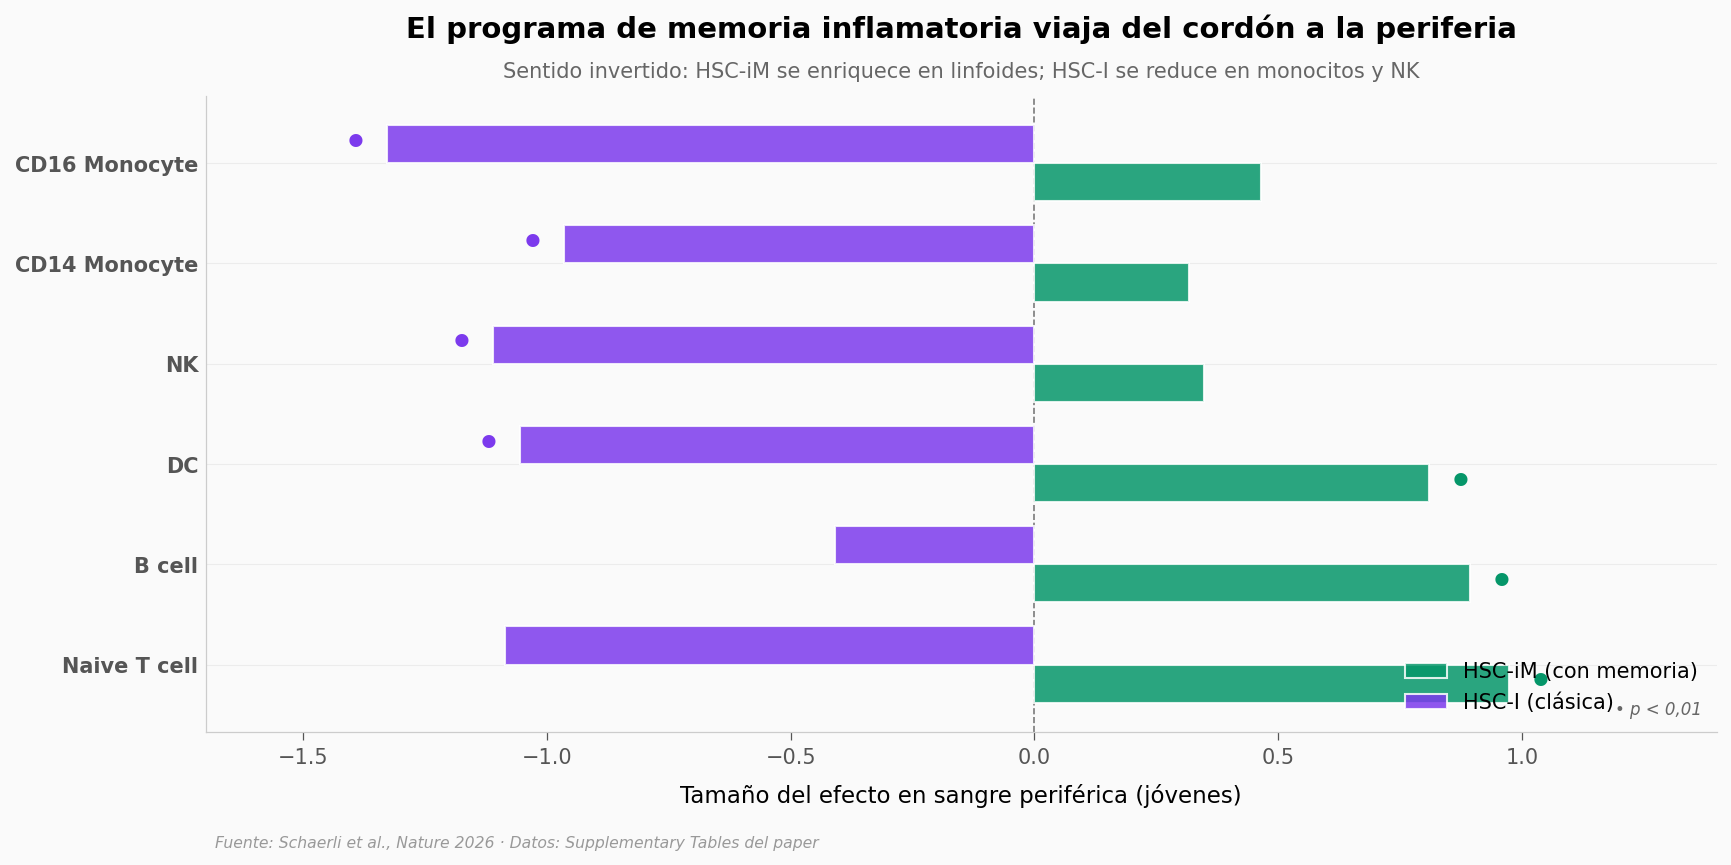

In [4]:
# ───── Effect sizes en sangre periférica, cohorte joven (Fig 5j) ─────
fig, ax = plt.subplots(figsize=(13, 5.5))

joven = ds4[ds4.cohorte == 'Joven'].copy()
tipos_orden = ['Naive T cell', 'B cell', 'DC', 'NK', 'CD14 Monocyte', 'CD16 Monocyte']
joven = joven.set_index(['programa', 'tipo_celular'])

y_pos = np.arange(len(tipos_orden))
height = 0.38
es_hscim = joven.loc['HSC-iM'].loc[tipos_orden, 'effect_size'].values
es_hsci = joven.loc['HSC-I'].loc[tipos_orden, 'effect_size'].values
p_hscim = joven.loc['HSC-iM'].loc[tipos_orden, 'neg_log10_p'].values
p_hsci = joven.loc['HSC-I'].loc[tipos_orden, 'neg_log10_p'].values

ax.barh(y_pos - height/2, es_hscim, height=height, color=COLOR_HSC_iM, alpha=0.85,
        edgecolor='white', linewidth=1.0, label='HSC-iM (con memoria)', zorder=3)
ax.barh(y_pos + height/2, es_hsci, height=height, color=COLOR_HSC_I, alpha=0.85,
        edgecolor='white', linewidth=1.0, label='HSC-I (clásica)', zorder=3)
ax.axvline(0, color='#444444', linewidth=0.8, linestyle='--', alpha=0.7, zorder=2)

# Marcar p<0.01 con estrella
for i, p in enumerate(p_hscim):
    if p >= 2:
        ax.text(es_hscim[i] + 0.04, i - height/2, '•', fontsize=18,
                color=COLOR_HSC_iM, va='center', fontweight='bold')
for i, p in enumerate(p_hsci):
    if p >= 2:
        ax.text(es_hsci[i] - 0.04, i + height/2, '•', fontsize=18,
                color=COLOR_HSC_I, va='center', fontweight='bold', ha='right')

ax.set_yticks(y_pos)
ax.set_yticklabels(tipos_orden, fontsize=10, fontweight='bold')
ax.set_xlabel('Tamaño del efecto en sangre periférica (jóvenes)', fontsize=11)
ax.set_xlim(-1.7, 1.4)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_title('El programa de memoria inflamatoria viaja del cordón a la periferia',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Sentido invertido: HSC-iM se enriquece en linfoides; HSC-I se reduce en monocitos y NK',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.99, 0.02, '• p < 0,01', transform=ax.transAxes, fontsize=8,
        color='#666666', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/efectos_periferia.png', dpi=200, bbox_inches='tight')
plt.show()

HSC-iM aparece amplificada en linfocitos T y B y células dendríticas; HSC-I aparece deprimida en monocitos y NK. Es una huella con dos lados — y los dos llegan a la sangre que circula.

Falta un último paso. Hasta aquí los datos son experimentales (en xenografts) y descriptivos (en sangre joven). La prueba más fuerte de relevancia sería encontrar el programa HSC-iM **enriquecido en condiciones humanas donde la médula sufre estrés crónico** — por ejemplo, en hematopoyesis clonal (CH), donde un clon de HSCs con mutaciones somáticas (TET2, DNMT3A) crece silenciosamente con la edad.

Si HSC-iM tiene relevancia fisiológica, debería verse más en sujetos con CH que en controles.

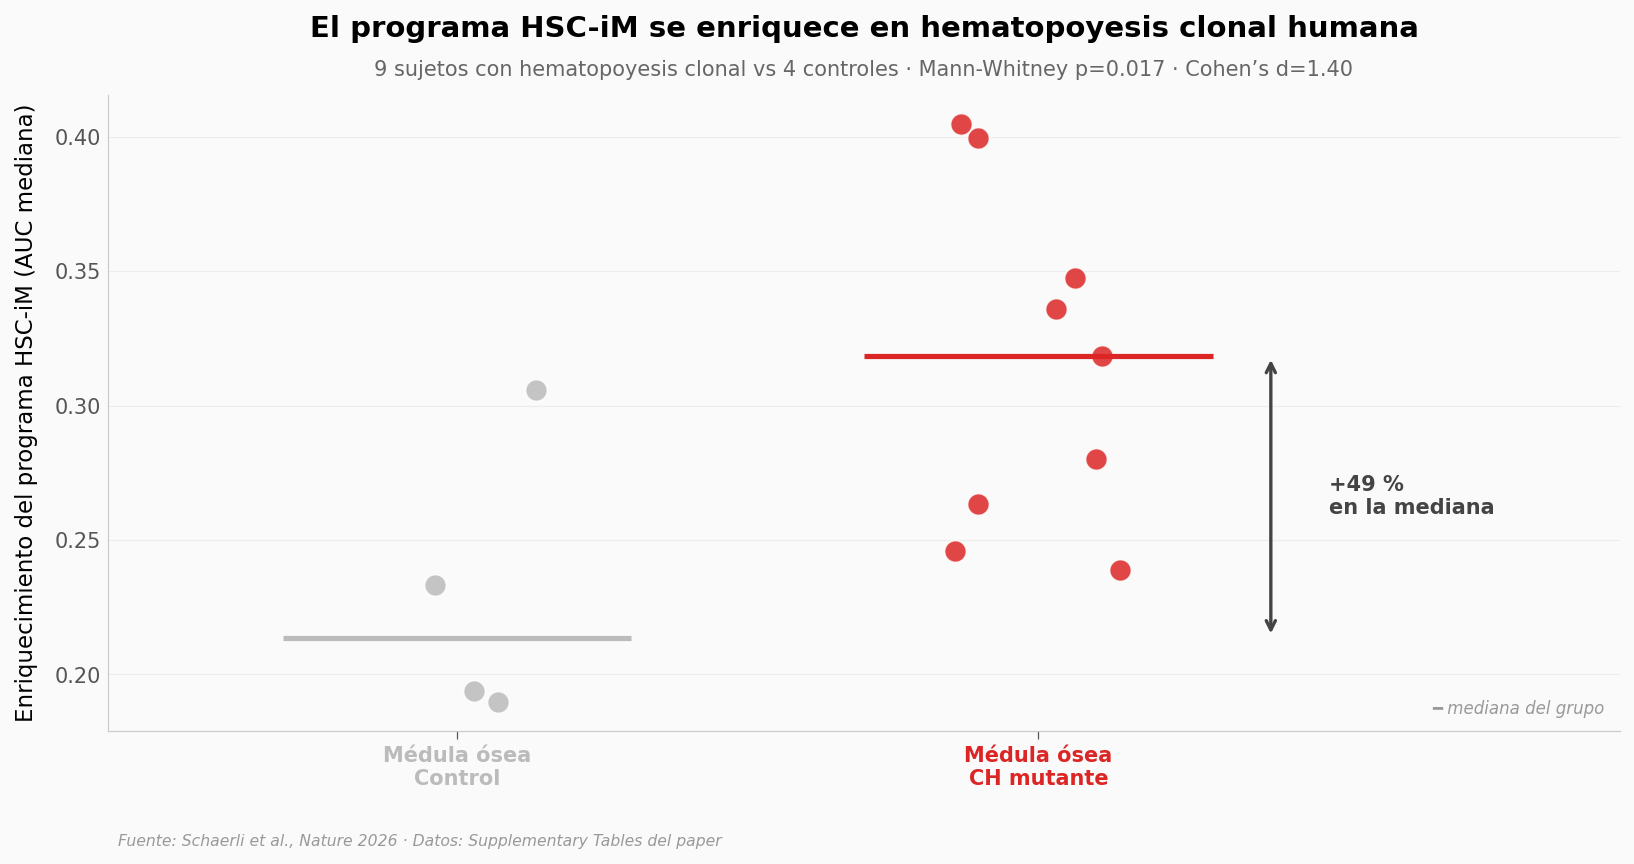

Spearman ρ(fracción mutante BM, HSC-iM AUC) = 0.73 · p = 0.005 · n = 13


In [5]:
# ───── HSC-iM AUC: Control vs CH humano (Fig 4h) ─────
fig, ax = plt.subplots(figsize=(13, 5.5))

ctrl = ds3[ds3.estado_ch == 'Control']['hscim_auc_mediana'].values
ch = ds3[ds3.estado_ch != 'Control']['hscim_auc_mediana'].values

# Strip plot
np.random.seed(42)
x_ctrl = np.random.uniform(0.85, 1.15, len(ctrl))
x_ch = np.random.uniform(1.85, 2.15, len(ch))

ax.scatter(x_ctrl, ctrl, color=COLOR_CONTROL, s=110, alpha=0.85,
           edgecolors='white', linewidths=0.8, zorder=5, label=f'Control (n={len(ctrl)})')
ax.scatter(x_ch, ch, color=COLOR_CH, s=110, alpha=0.85,
           edgecolors='white', linewidths=0.8, zorder=5,
           label=f'Hematopoyesis clonal (n={len(ch)})')

# Líneas de mediana
med_ctrl = np.median(ctrl)
med_ch = np.median(ch)
ax.hlines(med_ctrl, 0.7, 1.3, colors=COLOR_CONTROL, linewidth=2.5, zorder=6)
ax.hlines(med_ch, 1.7, 2.3, colors=COLOR_CH, linewidth=2.5, zorder=6)

# Flecha del delta
delta_pct = (med_ch - med_ctrl) / med_ctrl * 100
ax.annotate('', xy=(2.4, med_ch), xytext=(2.4, med_ctrl),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.6))
ax.text(2.5, (med_ctrl + med_ch) / 2,
        f'+{delta_pct:.0f} %\nen la mediana',
        fontsize=10, fontweight='bold', color='#444444', va='center')

# Test Mann-Whitney + Cohen's d
_, p = stats.mannwhitneyu(ch, ctrl, alternative='greater')
pooled_sd = np.sqrt(((len(ctrl)-1)*ctrl.var(ddof=1) + (len(ch)-1)*ch.var(ddof=1)) / (len(ctrl)+len(ch)-2))
d = (ch.mean() - ctrl.mean()) / pooled_sd

ax.set_xticks([1, 2])
ax.set_xticklabels(['Médula ósea\nControl', 'Médula ósea\nCH mutante'],
                   fontsize=10, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), [COLOR_CONTROL, COLOR_CH]):
    tick.set_color(col)
ax.set_ylabel('Enriquecimiento del programa HSC-iM (AUC mediana)', fontsize=11)
ax.set_xlim(0.4, 3.0)

ax.set_title('El programa HSC-iM se enriquece en hematopoyesis clonal humana',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'9 sujetos con hematopoyesis clonal vs 4 controles · Mann-Whitney p={p:.3f} · Cohen\u2019s d={d:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.99, 0.02, '━ mediana del grupo', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hscim_ch_humana.png', dpi=200, bbox_inches='tight')
plt.show()

# Correlación Spearman con la fracción mutante (sin Controles, que son 0)
rho, p_rho = stats.spearmanr(ds3.fraccion_celulas_mutantes_bm, ds3.hscim_auc_mediana)
print(f'Spearman ρ(fracción mutante BM, HSC-iM AUC) = {rho:.2f} · p = {p_rho:.3f} · n = {len(ds3)}')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El estrés inflamatorio reduce la frecuencia de HSCs en el xenograft humano | ✅ | Mediana 39,5 % → 19,2 % (TNFα, −51 % en mediana, d=1,93, p=3,3·10⁻⁵) y → 11,7 % (LPS, −70 % en mediana, d=2,53, p=10⁻⁵). 14-15 réplicas por brazo, 3 donantes — efecto consistente entre donantes. |
| Las HSCs sobrevivientes contienen dos subsets: HSC-I clásica y HSC-iM con memoria | ✅ | Firma LT-HSC en RNA y ATAC sitúa a HSC-II/HSC-iM cerca de HSC-I (RNA: 0,49 vs 1,00 · ATAC: 0,51 vs 0,69) y muy lejos de LMPP-II (−1,06). HSC-iM preserva identidad LT-HSC; los demás subsets-II la pierden. |
| El programa HSC-iM se enriquece en personas con hematopoyesis clonal y correlaciona con la carga mutacional | ⚠️ | Control n=4, CH n=9: +49 % en mediana, d=1,40, p=0,017 (Mann-Whitney). Spearman ρ(fracción mutante, AUC)=0,73 (p=0,005, n=13). Datos observacionales: el paper lo enmarca como asociación, no causalidad. |
| La huella HSC-iM llega a células sanguíneas circulantes | ✅ | Effect sizes positivos para HSC-iM en linfocitos B (+0,89, p≈10⁻³·³) y T naive (+0,97) y DC (+0,81); negativos para HSC-I en monocitos CD16 (−1,33) y NK (−1,11). Patrón inverso entre los dos programas. |
| El programa HSC-iM en sangre periférica se asocia con riesgo elevado de mortalidad por todas las causas | ⚠️ | Reportado por el paper en cohortes poblacionales con datos restringidos (Ontario Health Study); no graficamos aquí. **Asociación**, no causalidad — y el paper lo enmarca como estimación. |

> **Limitaciones.** El xenograft es un buen modelo de identidad HSC humana pero no replica todo el nicho de médula adulta. La cohorte CH tiene 13 sujetos y mezcla mutaciones (TET2, DNMT3A, doble) — no se puede separar el efecto por gen. La cohorte de sangre joven es donadora sana sin historia clínica detallada — la huella "joven" no incluye estrés agudo previo conocido.

## Ahora tú

Hay tres preguntas que los datos cargados (`ds3`, `ds4`) permiten explorar sin información adicional:

1. **¿Cómo se compara la huella HSC-iM entre cohorte joven y mayor?** Los datos `ds4` traen ambas cohortes. Pista: `ds4[ds4.programa == 'HSC-iM'].groupby('cohorte').effect_size.mean()`. Ojo: la cohorte mayor tiene menos muestras y los effect sizes serán más ruidosos.

2. **¿Qué tipo celular cambia más entre joven y mayor?** El delta de effect size por tipo celular puede revelar si algún linaje concentra el cambio. Pista: `pivot` por tipo y restar.

3. **¿Las mutaciones de un solo gen vs dos genes producen AUC distinta?** En `ds3`, comparar AUC mediana entre `DNMT3A`, `TET2` y `DNMT3A_TET2`. Cuidado: n=1 para doble mutante — cualquier diferencia es anecdótica, no estadística.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿La huella HSC-iM se intensifica con la edad?

resumen = (ds4[ds4.programa == 'HSC-iM']
           .groupby('cohorte')
           .agg(effect_medio=('effect_size', 'mean'),
                effect_max=('effect_size', 'max'),
                n_tipos=('tipo_celular', 'count')))
print('=== HSC-iM por cohorte ===')
print(resumen.round(3))
print()

# Comparar tipo a tipo
pivot = ds4[ds4.programa == 'HSC-iM'].pivot(index='tipo_celular',
                                            columns='cohorte',
                                            values='effect_size')
pivot['delta_mayor_joven'] = pivot['Mayor'] - pivot['Joven']
print('=== Cambio Mayor − Joven por tipo celular (HSC-iM) ===')
print(pivot.sort_values('delta_mayor_joven', ascending=False).round(3))
print()
print('Lectura: positivo = la huella crece con la edad en ese tipo celular.')
print('Cuidado: cohorte Mayor tiene tamaños muestrales menores — los effect sizes pueden ser más ruidosos.')

=== HSC-iM por cohorte ===
         effect_medio  effect_max  n_tipos
cohorte                                   
Joven           0.634       0.973        6
Mayor           0.291       0.584        6

=== Cambio Mayor − Joven por tipo celular (HSC-iM) ===
cohorte        Joven  Mayor  delta_mayor_joven
tipo_celular                                  
CD16 Monocyte  0.464  0.584              0.120
NK             0.349  0.235             -0.114
Naive T cell   0.973  0.567             -0.406
CD14 Monocyte  0.316 -0.104             -0.420
B cell         0.893  0.346             -0.547
DC             0.809  0.116             -0.693

Lectura: positivo = la huella crece con la edad en ese tipo celular.
Cuidado: cohorte Mayor tiene tamaños muestrales menores — los effect sizes pueden ser más ruidosos.


## Fuentes

**Paper**: [Human haematopoietic stem cells remember inflammatory stress](https://doi.org/10.1038/s41586-026-10522-7)  
*Nature, 2026-05-27*

**Supplementary Material** (Tablas de datos del mismo paper):
- [MOESM5](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10522-7/MediaObjects/41586_2026_10522_MOESM5_ESM.xlsx) — *Fig 1g — frecuencia HSCs en xenograft (PBS/TNFα/LPS)*
- [MOESM6](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10522-7/MediaObjects/41586_2026_10522_MOESM6_ESM.xlsx) — *Fig 2c/2d — firma LT-HSC por subset (RNA + ATAC)*
- [MOESM8](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10522-7/MediaObjects/41586_2026_10522_MOESM8_ESM.xlsx) — *Fig 4h — HSC-iM en hematopoyesis clonal humana*
- [MOESM9](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10522-7/MediaObjects/41586_2026_10522_MOESM9_ESM.xlsx) — *Fig 5j — effect sizes en sangre periférica*

**Código del paper:**
- [Zenodo](https://doi.org/10.5281/zenodo.18850871)

*15 afirmaciones verificadas contra estas fuentes*

---

*Notebook reproducible · [Repo en GitHub](https://github.com/Ciencia-a-Mordiscos/lab) · Estilo CaM (cam.mplstyle)*